--- Model Results ---
Overall Accuracy: 100.00%

--- Diagnosis Demonstration ---
Patient 1: Actual Heart Disease: Yes, Predicted Diagnosis: Yes
Patient 2: Actual Heart Disease: Yes, Predicted Diagnosis: Yes


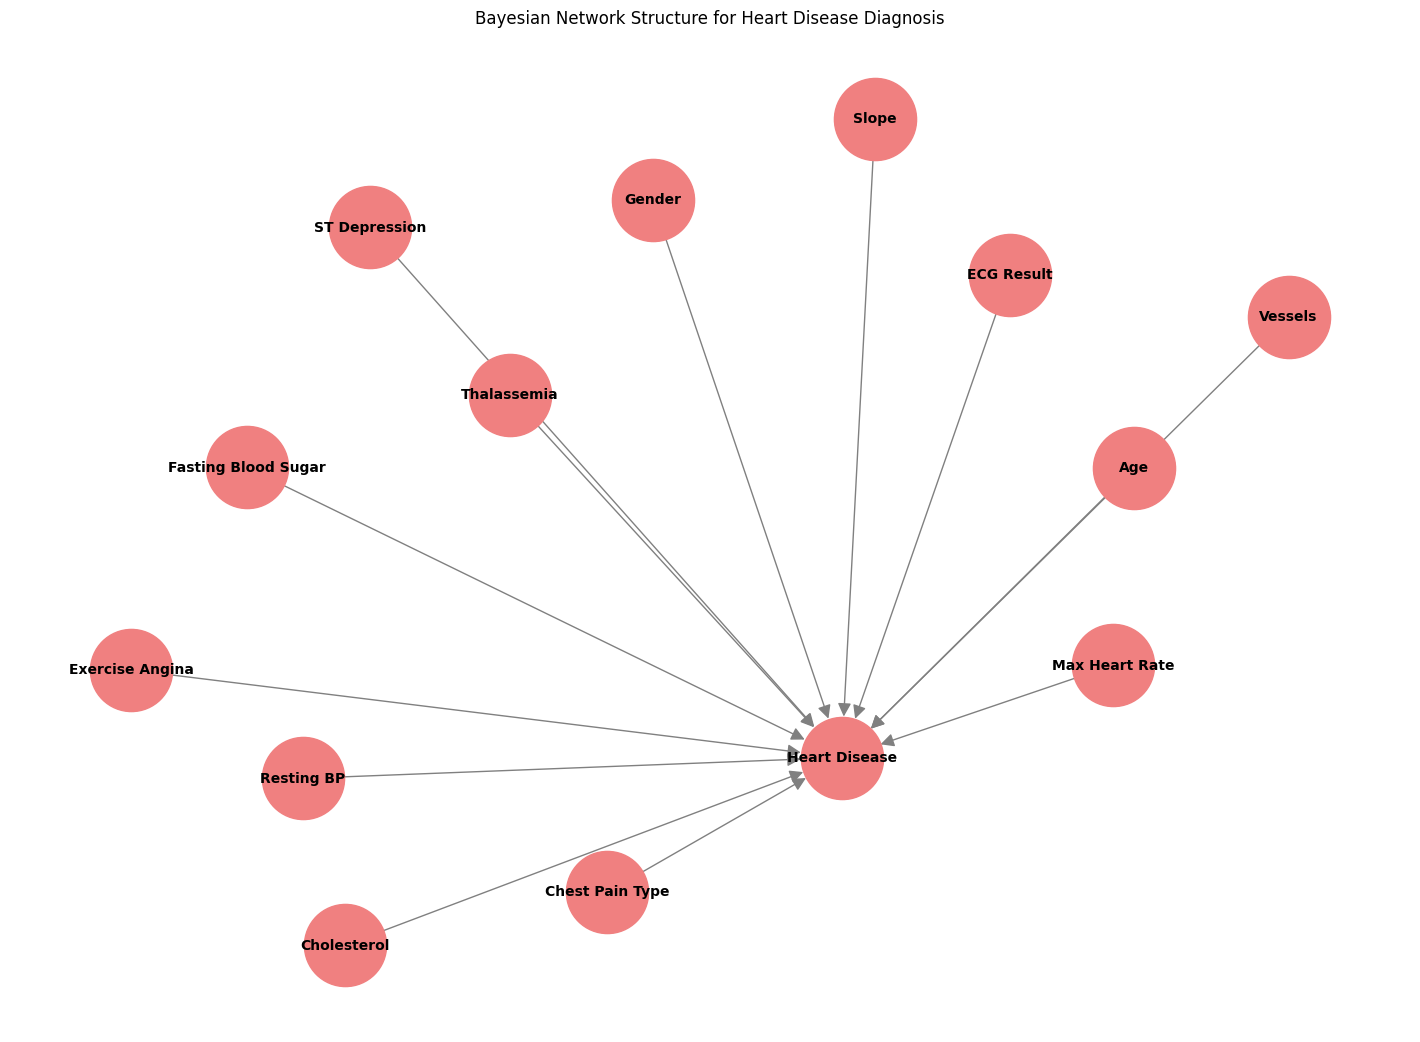

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer
from sklearn.metrics import accuracy_score

# 1. Load the Heart Disease Dataset
df = pd.read_csv('Heart.csv')

# 2. Define Features and Target
target = 'Heart Disease'
num_cols = ['Age', 'Resting BP', 'Cholesterol', 'Max Heart Rate', 'ST Depression']
cat_cols = [c for c in df.columns if c not in num_cols and c != target]

# 3. Preprocessing: Encoding and Discretization
# Encode categorical data
le_dict = {}
for col in cat_cols + [target]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# Discretize continuous numerical data into bins (for Bayesian logic)
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
df[num_cols] = kbd.fit_transform(df[num_cols])

# 4. Construct and Train the Bayesian Model
X = df.drop(columns=[target])
y = df[target]

# Using Categorical Naive Bayes as the Bayesian Network implementation
model = CategoricalNB()
model.fit(X, y)

# 5. Model Evaluation
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)

print(f"--- Model Results ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

# 6. Demonstrate Diagnosis for Specific Patients
demo_indices = [0, 1]
print("\n--- Diagnosis Demonstration ---")
for idx in demo_indices:
    actual = "Yes" if y[idx] == 1 else "No"
    pred = "Yes" if y_pred[idx] == 1 else "No"
    print(f"Patient {idx+1}: Actual Heart Disease: {actual}, 
    Predicted Diagnosis: {pred}")

# 7. Plotting the Bayesian Network Structure
G = nx.DiGraph()
# In diagnostic Bayesian Networks, symptoms are often treated as effects of the disease
for col in X.columns:
    G.add_edge(col, target)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.8)
nx.draw(G, pos, with_labels=True, node_size=3500, node_color='lightcoral', 
        font_size=10, font_weight='bold', arrowsize=20, edge_color='gray')
plt.title("Bayesian Network Structure for Heart Disease Diagnosis")
plt.savefig('heart_disease_network.png')
plt.show()